# Set WD to Root

In [1]:
from pathlib import Path
import os

repo_root = Path.cwd().parents[0]
os.chdir(repo_root)

# print(Path.cwd())

# Load Model and Hyperparameters

In [2]:
import json

# 加载超参
PARAM_PATH = Path('./config/test_transformer_params.json')

with open(PARAM_PATH, "r", encoding="utf-8") as f:
    params = json.load(f)

print(params)


{'batch_size': 200, 'learning_rate': 0.01, 'epochs': 5000, 'embedding_dim': 100, 'num_heads': 4, 'num_layers': 3}


# Load Data and Tokenizer

In [3]:
from scripts.data_loader.piqa_dataloader import get_piqa_dataloaders
from pathlib import Path
import sentencepiece as spm

BASE_PATH = Path('./datasets/PIQA')
BASE_PATH = BASE_PATH.resolve()

tokenizer = spm.SentencePieceProcessor(
    model_file="./scripts/tokenizer/piqa_bpe_v3.model"
)

train_loader, validate_loader, test_loader = get_piqa_dataloaders(base_path=BASE_PATH,
                                                                  tokenizer=tokenizer,
                                                                  batch_size=params['batch_size'])

In [4]:
from scripts.models.transformer_bi_classifier import TransformerClassifier
import torch.optim as optim
import torch.nn.functional as F

# 初始化模型和优化器
tf_model = TransformerClassifier(vocab_size=tokenizer.vocab_size(),
                                 embedding_dim=params['embedding_dim'],
                                 padding_idx=tokenizer.pad_id(),
                                 max_seq_length=2048,   # 设为 2048 防止序列长度溢出
                                 num_heads=params['num_heads'],
                                 num_layers=params['num_layers'])

tf_optimiser = optim.SGD(params=tf_model.parameters(), lr=params['learning_rate'])
criterion = F.cross_entropy

# 训练循环

Batch size 不要超过 200，否则很容易内存溢出！

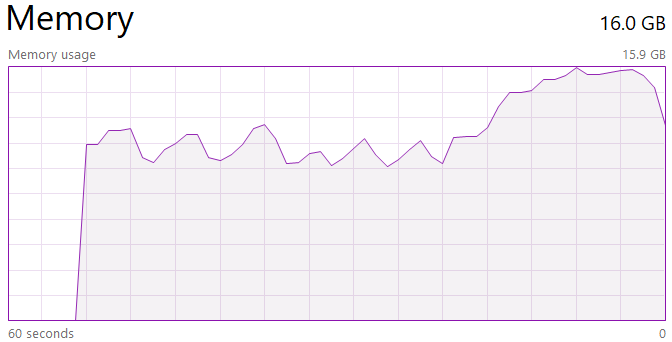

In [5]:
from time import perf_counter

tf_model.train()

epoch_loss = 0.0

for input_1, input_2, mask_1, mask_2, labels in train_loader:

    start_ts = perf_counter()
    # Forward
    tf_optimiser.zero_grad()

    logits = tf_model.forward(input_1, input_2, mask_1, mask_2)

    # Loss
    loss = criterion(
        input=logits,
        target=labels
    )

    # Backward
    loss.backward()

    tf_optimiser.step()

    # Record loss
    epoch_loss += loss.item()

    end_ts = perf_counter()
    time_elips = end_ts - start_ts
    
    print(
        f"time={time_elips:.2f}, "
        f"loss={loss.item():.2f}"
    )


time=9.06, loss=0.73
time=12.16, loss=0.71


KeyboardInterrupt: 

# 取出注意力矩阵 Weight

In [ ]:
# 取出注意力投影矩阵
W_Q, W_K, W_V = attn.in_proj_weight.chunk(3, dim=0)

print(W_Q.shape)
print(W_K.shape)
print(W_V.shape)

# torch.Size([100, 100])
# torch.Size([100, 100])
# torch.Size([100, 100])

# 如何自己拆成多头注意力？？

torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])


In [15]:
layer = tf_model.encoder.layers[0]

attn = layer.self_attn

print(attn)

MultiheadAttention(
  (out_proj): NonDynamicallyQuantizableLinear(in_features=100, out_features=100, bias=True)
)


In [32]:
from scripts.models.transformer_attention_tools import *

In [33]:
input_1, input_2, mask_1, mask_2, labels = next(iter(test_loader))


In [34]:
attentions = extract_encoder_attentions(
    tf_model,
    input_1,
    mask_1
)

In [35]:
print(attentions[0].shape)
print(attentions[1].shape)

torch.Size([200, 4, 132, 132])
torch.Size([200, 4, 132, 132])


In [36]:
# mask_1: [B, L]
seq_lengths = mask_1.sum(dim=1)

# 最短序列的样本索引
shortest_idx = seq_lengths.argmin().item()

print("Sample index:", shortest_idx)
print("Sequence length:", seq_lengths[shortest_idx].item())

Sample index: 144
Sequence length: 7


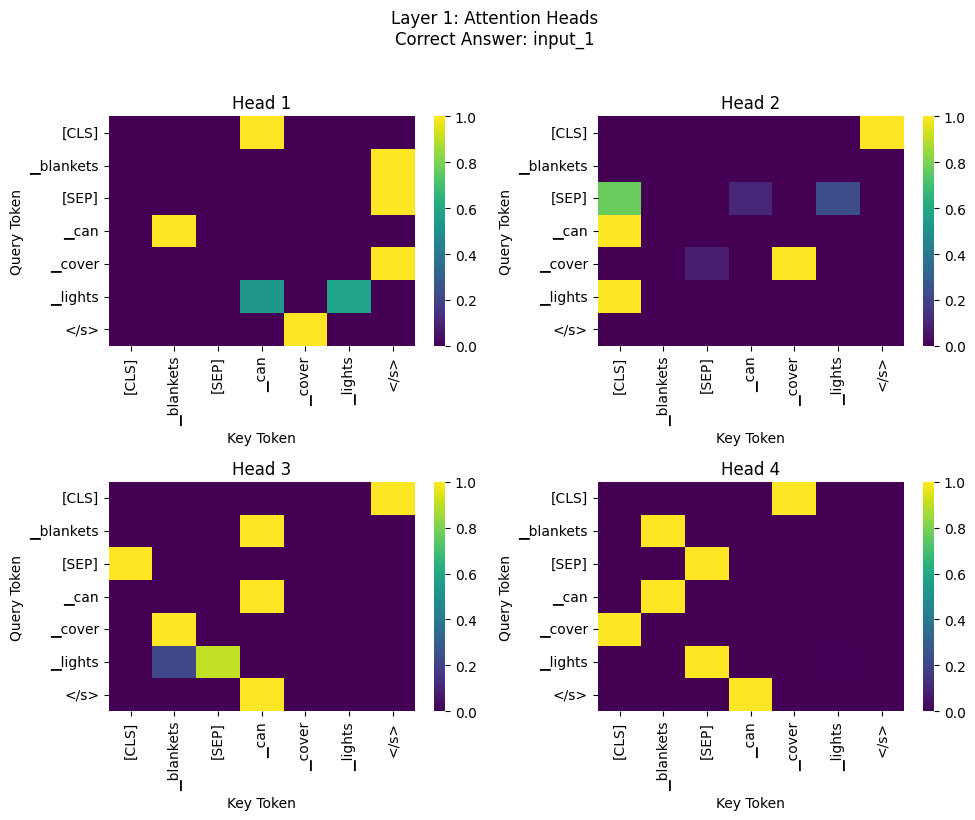

In [37]:
plot_attention_heads(
    attentions,
    layer_idx=0,
    sample_idx=shortest_idx,
    input_ids=input_1,
    tokenizer=tokenizer,
    mask=mask_1,
    labels=labels
)